#### (b)

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import src.util as util

from src.linear_model import LinearModel

In [24]:
ds1_training_set_path = 'data/ds1_train.csv'
ds1_valid_set_path = 'data/ds1_valid.csv'
ds2_training_set_path = 'data/ds2_train.csv'
ds2_valid_set_path = 'data/ds2_valid.csv'

In [25]:
x_train, y_train = util.load_dataset(ds1_training_set_path, add_intercept=True)
x_valid, y_valid = util.load_dataset(ds1_valid_set_path, add_intercept=True)

# x_train, y_train = util.load_dataset(ds2_training_set_path, add_intercept=True)
# x_valid, y_valid = util.load_dataset(ds2_valid_set_path, add_intercept=True)

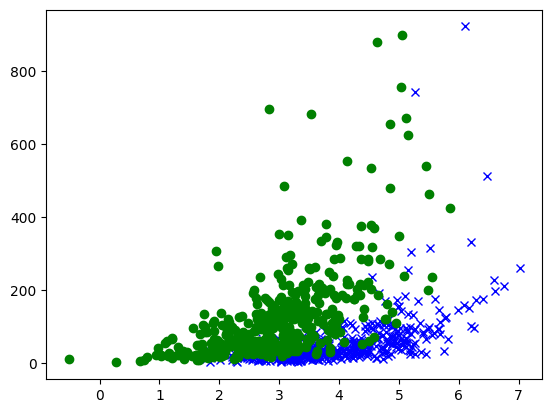

In [26]:
plt.plot(x_train[y_train == 1, -2], x_train[y_train == 1, -1], 'bx', linewidth=2)
plt.plot(x_train[y_train == 0, -2], x_train[y_train == 0, -1], 'go', linewidth=2)

In [27]:
class LogisticRegression(LinearModel):
    """Logistic regression with Newton's Method as the solver.

    Example usage:
        > clf = LogisticRegression()
        > clf.fit(x_train, y_train)
        > clf.predict(x_eval)
    """

    def fit(self, x, y):
        """Run Newton's Method to minimize J(theta) for logistic regression.

        Args:
            x: Training example inputs. Shape (m, n).
            y: Training example labels. Shape (m,).
        """
        # *** START CODE HERE ***
        
        def h(theta, x):
            """
            x: (m, n)
            return (m, )
            """
            return 1 / (1+np.exp(-(x @ theta)))
        
        def gradient(theta, x, y):
            m, _ = x.shape
            return -1/m * x.T @ (y-h(theta, x))
        
        def hessian(theta, x):
            """
            (n,m) x (m, ) * 
            """
            m, _ = x.shape
            return 1/m * x.T @ np.diag(h(theta, x) * (1-h(theta,x))) @ x
            
        m,n = x.shape
        if self.theta is None:
            self.theta = np.zeros(n)
        self.theta = self.theta - np.linalg.inv(hessian(self.theta, x)) @ gradient(self.theta, x, y)
        # *** END CODE HERE ***

    def predict(self, x):
        """Make a prediction given new inputs x.

        Args:
            x: Inputs of shape (m, n).

        Returns:
            Outputs of shape (m,).
        """
        # *** START CODE HERE ***
        # *** END CODE HERE ***
        return x @ self.theta >= 0

In [28]:
log_reg = LogisticRegression()

Theta =  [-6.26018491  2.47707251 -0.0299125 ]
Accuracy is 0.8825


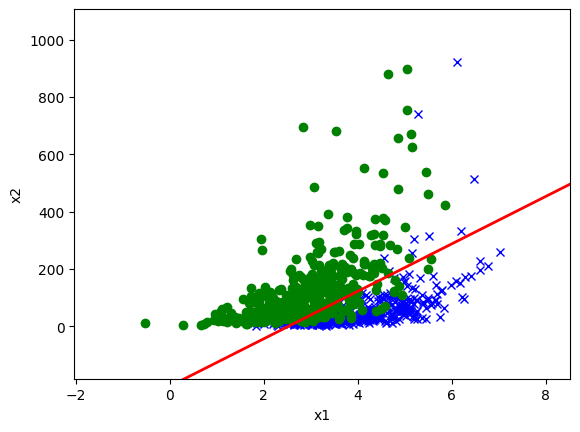

In [29]:
for i in range(100):
    log_reg.fit(x_train, y_train)
util.plot(x_train, y_train, log_reg.theta)
print("Theta = ", log_reg.theta)
print("Accuracy is", np.mean(log_reg.predict(x_train)==y_train))

Accuracy is 0.9


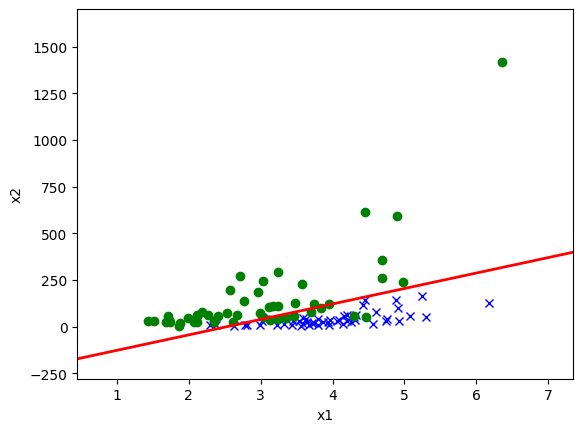

In [30]:
util.plot(x_valid, y_valid, log_reg.theta)
print("Accuracy is", np.mean(log_reg.predict(x_valid)==y_valid))

#### (e)

In [31]:
class GDA(LinearModel):
    """Gaussian Discriminant Analysis.

    Example usage:
        > clf = GDA()
        > clf.fit(x_train, y_train)
        > clf.predict(x_eval)
    """

    def fit(self, x, y):
        """Fit a GDA model to training set given by x and y.

        Args:
            x: Training example inputs. Shape (m, n).
            y: Training example labels. Shape (m,).

        Returns:
            theta: GDA model parameters.
        """
        # *** START CODE HERE ***
        
        x_raw = x[:, 1:]
        
        m,n = x_raw.shape
        phi = 1/m * np.sum(y==1)
        
        mu_0 = np.sum(x_raw[y==0], 0)/np.sum(y==0)
        mu_1 = np.sum(x_raw[y==1], 0)/np.sum(y==1)
        
        centered = np.zeros_like(x_raw)
        centered[y==0] = x_raw[y==0] - mu_0
        centered[y==1] = x_raw[y==1] - mu_1
        
        sigma = 1/m * centered.T @ centered
        print(sigma, sigma.shape)
        
        theta = (mu_1-mu_0) @ np.linalg.inv(sigma)
        theta_0 = 1/2 * (mu_0+mu_1).T @ np.linalg.inv(sigma) @ (mu_0-mu_1) - np.log((1-phi)/phi)
        
        self.theta = np.insert(theta, 0 , theta_0)
        # *** END CODE HERE ***

    def predict(self, x):
        """Make a prediction given new inputs x.

        Args:
            x: Inputs of shape (m, n).

        Returns:
            Outputs of shape (m,).
        """
        # *** START CODE HERE ***
        # *** END CODE HERE ***
        return x @ self.theta >= 0


[[9.53653342e-01 5.87339678e+01]
 [5.87339678e+01 1.15818332e+04]] (2, 2)
Theta =  [-6.17158405  2.22055506 -0.01763375]
Accuracy is 0.86625


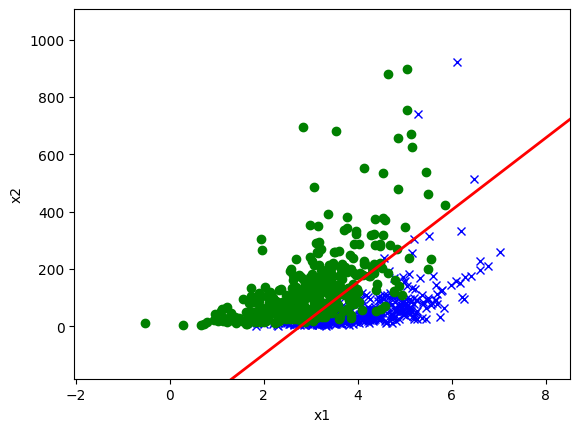

In [32]:
gda = GDA()
gda.fit(x_train, y_train)
util.plot(x_train, y_train, gda.theta)
print("Theta = ", gda.theta)
print("Accuracy is", np.mean(gda.predict(x_train)==y_train))

Accuracy is 0.83


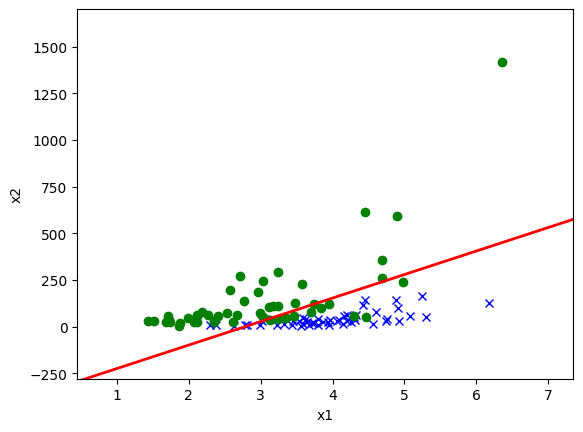

In [33]:
util.plot(x_valid, y_valid, gda.theta)
print("Accuracy is", np.mean(gda.predict(x_valid)==y_valid))